In [29]:
cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "annual_inc",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "gdp_growth_t1",
    "unemployment_rate_t1",
    "fedfunds_t1",
    "inflation_t1",
    "housing_price_t1",
    "gdp_growth_t2",
    "unemployment_rate_t2",
    "fedfunds_t2",
    "inflation_t2",
    "housing_price_t2",
    "gdp_growth_t3",
    "unemployment_rate_t3",
    "fedfunds_t3",
    "inflation_t3",
    "housing_price_t3",
    "gdp_growth_t4",
    "unemployment_rate_t4",
    "fedfunds_t4",
    "inflation_t4",
    "housing_price_t4",
    "gdp_growth_t5",
    "unemployment_rate_t5",
    "fedfunds_t5",
    "inflation_t5",
    "housing_price_t5",
    "revol_util_t1",
    "revol_util_t2",
    "revol_util_t3",
    "revol_util_t4",
    "revol_bal_t1",
    "revol_bal_t2",
    "revol_bal_t3",
    "revol_bal_t4",
    "out_prncp_t1",
    "out_prncp_t2",
    "out_prncp_t3",
    "out_prncp_t4",
    "total_pymnt_t1",
    "total_pymnt_t2",
    "total_pymnt_t3",
    "total_pymnt_t4",
    "last_pymnt_amnt_t1",
    "last_pymnt_amnt_t2",
    "last_pymnt_amnt_t3",
    "last_pymnt_amnt_t4",
]

In [30]:
import pandas as pd

df = pd.read_csv('rebalanced_age_data.csv')
df = df.dropna(subset=cols)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_6184/4162594058.py:3: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('rebalanced_age_data.csv')


In [31]:
nan_count = df[cols].isnull().sum()
print(nan_count)

loan_amnt               0
int_rate                0
installment             0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
annual_inc              0
delinq_2yrs             0
inq_last_6mths          0
open_acc                0
gdp_growth_t1           0
unemployment_rate_t1    0
fedfunds_t1             0
inflation_t1            0
housing_price_t1        0
gdp_growth_t2           0
unemployment_rate_t2    0
fedfunds_t2             0
inflation_t2            0
housing_price_t2        0
gdp_growth_t3           0
unemployment_rate_t3    0
fedfunds_t3             0
inflation_t3            0
housing_price_t3        0
gdp_growth_t4           0
unemployment_rate_t4    0
fedfunds_t4             0
inflation_t4            0
housing_price_t4        0
gdp_growth_t5           0
unemployment_rate_t5    0
fedfunds_t5             0
inflation_t5            0
housing_price_t5        0
revol_util_t1           0
revol_util_t2           0
revol_util_t

In [32]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3  # Number of bins you want to create

# Initialize the discretizer; you can choose 'uniform' for equal-width,
# 'quantile' for equal-frequency, or 'kmeans' for clustering-based discretization.
kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans')

# Assuming df contains only the columns you want to discretize (or select them)
df_subset = df[cols].copy()
df_subset_discretized = pd.DataFrame(
    kbd.fit_transform(df_subset),
    columns=[col + '_disc' for col in cols]
)

# Merge the discretized columns back to the original DataFrame if needed
df = pd.concat([df, df_subset_discretized], axis=1)

print(df.head())

           id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277.0        NaN     3600.0       3600.0           3600.0   36 months   
1  68338832.0        NaN     1400.0       1400.0           1400.0   36 months   
2  68436666.0        NaN     5000.0       5000.0           5000.0   36 months   
3  67849662.0        NaN     4225.0       4225.0           4225.0   36 months   
4  68387134.0        NaN     2500.0       2500.0           2500.0   36 months   

   int_rate  installment grade sub_grade  ... out_prncp_t3_disc  \
0     13.99       123.03     C        C4  ...               0.0   
1     12.88        47.10     C        C2  ...               0.0   
2     13.44       169.54     C        C3  ...               0.0   
3     14.85       146.16     C        C5  ...               0.0   
4     17.27        89.47     D        D3  ...               0.0   

  out_prncp_t4_disc total_pymnt_t1_disc  total_pymnt_t2_disc  \
0               0.0                 2.0       

Unique values in 'inflation_t2_disc': [ 0.  2.  1. nan]


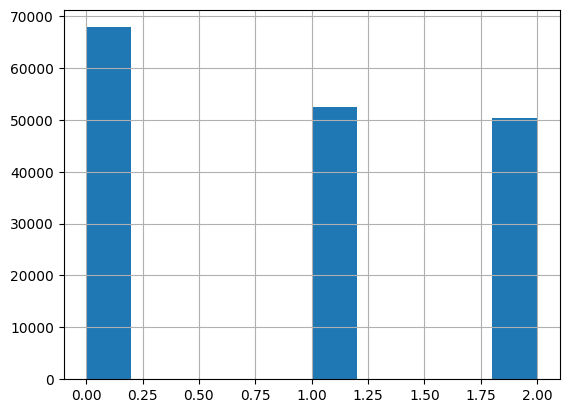

In [33]:
df["inflation_t2_disc"].hist()
unique_values = df["inflation_t2_disc"].unique()
print(f"Unique values in 'inflation_t2_disc': {unique_values}")

In [36]:
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
    "gdp_growth_t2_disc",
    "unemployment_rate_t2_disc",
    "fedfunds_t2_disc",
    "inflation_t2_disc",
    "housing_price_t2_disc",
    "gdp_growth_t3_disc",
    "unemployment_rate_t3_disc",
    "fedfunds_t3_disc",
    "inflation_t3_disc",
    "housing_price_t3_disc",
    "gdp_growth_t4_disc",
    "unemployment_rate_t4_disc",
    "fedfunds_t4_disc",
    "inflation_t4_disc",
    "housing_price_t4_disc",
    "gdp_growth_t5_disc",
    "unemployment_rate_t5_disc",
    "fedfunds_t5_disc",
    "inflation_t5_disc",
    "housing_price_t5_disc",
    "revol_util_t1_disc",
    "revol_util_t2_disc",
    "revol_util_t3_disc",
    "revol_util_t4_disc",
    "revol_bal_t1_disc",
    "revol_bal_t2_disc",
    "revol_bal_t3_disc",
    "revol_bal_t4_disc",
    "out_prncp_t1_disc",
    "out_prncp_t2_disc",
    "out_prncp_t3_disc",
    "out_prncp_t4_disc",
    "delinq_count_t1",
    "delinq_count_t2",
    "delinq_count_t3",
    "delinq_count_t4",
    "total_pymnt_t1_disc",
    "total_pymnt_t2_disc",
    "total_pymnt_t3_disc",
    "total_pymnt_t4_disc",
    "last_pymnt_amnt_t1_disc",
    "last_pymnt_amnt_t2_disc",
    "last_pymnt_amnt_t3_disc",
    "last_pymnt_amnt_t4_disc",
    "fico_bucket_pct_t0",
    "fico_bucket_pct_t1",
    "fico_bucket_pct_t2",
    "fico_bucket_pct_t3",
    "fico_bucket_pct_t4",
    "default_indicator_t1",
    "default_indicator_t2",
    "default_indicator_t3",
    "default_indicator_t4",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "age_group",
    "issue_quarter",
]

In [37]:
df = df[cols]

In [38]:
import re

# Define a function to decide if a column should be transformed.
def should_transform(col_name):
    pattern = r"^(gdp_growth|unemployment_rate|fedfunds|inflation|housing_price)_t\d+_disc$"
    return re.search(pattern, col_name) is not None

# Define the function to shift the time suffix by subtracting one.
def shift_time_suffix(col_name):
    if not should_transform(col_name):
        return col_name
    pattern = r"_t(\d+)"
    def replace(match):
        time_index = int(match.group(1))
        new_time_index = time_index - 1 if time_index >= 1 else time_index
        return f"_t{new_time_index}"
    new_col = re.sub(pattern, replace, col_name)
    return new_col

# Create a mapping from original to transformed column names.
rename_mapping = {col: shift_time_suffix(col) for col in df.columns}

# Rename the DataFrame columns using the mapping.
df = df.rename(columns=rename_mapping)

In [39]:
import pandas as pd
import re

# Define the function to swap the order of '_t#' and '_disc' in a column name.
def swap_column_order(col_name):
    """
    Swap the order of '_t#' and '_disc' if both are present in the column name.
    For example, 'gdp_growth_t0_disc' becomes 'gdp_growth_disc_t0'.
    """
    # Regex explanation:
    # (.*)    -> all characters before the '_t#' sequence
    # (_t\d+) -> '_t' followed by one or more digits
    # (_disc) -> literal '_disc'
    # (.*)    -> any trailing characters after '_disc'
    pattern = r'^(.*)(_t\d+)(_disc)(.*)$'
    match = re.match(pattern, col_name)
    if match:
        prefix, t_part, disc_part, suffix = match.groups()
        new_col_name = f"{prefix}{disc_part}{t_part}{suffix}"
        return new_col_name
    else:
        # Return original column name if pattern is not matched
        return col_name

# Before renaming
print("Original DataFrame columns:")
print(df.columns.tolist())

# Rename columns by applying the swap function
df.rename(columns=lambda x: swap_column_order(x), inplace=True)

# After renaming
print("\nUpdated DataFrame columns:")
print(df.columns.tolist())



Original DataFrame columns:
['loan_amnt_disc', 'int_rate_disc', 'installment_disc', 'pub_rec_disc', 'revol_bal_disc', 'revol_util_disc', 'total_acc_disc', 'annual_inc_disc', 'delinq_2yrs_disc', 'inq_last_6mths_disc', 'open_acc_disc', 'gdp_growth_t0_disc', 'unemployment_rate_t0_disc', 'fedfunds_t0_disc', 'inflation_t0_disc', 'housing_price_t0_disc', 'gdp_growth_t1_disc', 'unemployment_rate_t1_disc', 'fedfunds_t1_disc', 'inflation_t1_disc', 'housing_price_t1_disc', 'gdp_growth_t2_disc', 'unemployment_rate_t2_disc', 'fedfunds_t2_disc', 'inflation_t2_disc', 'housing_price_t2_disc', 'gdp_growth_t3_disc', 'unemployment_rate_t3_disc', 'fedfunds_t3_disc', 'inflation_t3_disc', 'housing_price_t3_disc', 'gdp_growth_t4_disc', 'unemployment_rate_t4_disc', 'fedfunds_t4_disc', 'inflation_t4_disc', 'housing_price_t4_disc', 'revol_util_t1_disc', 'revol_util_t2_disc', 'revol_util_t3_disc', 'revol_util_t4_disc', 'revol_bal_t1_disc', 'revol_bal_t2_disc', 'revol_bal_t3_disc', 'revol_bal_t4_disc', 'out_prnc

In [40]:
df.rename(columns={'revol_util_disc': 'revol_util_disc_t0'}, inplace=True)
df.rename(columns={'revol_bal_disc': 'revol_bal_disc_t0'}, inplace=True)

In [41]:
df["delinq_count_t0"] = 0
df["total_pymnt_disc_t0"] = 0
df["out_prncp_disc_t0"] = 0
df["last_pymnt_amnt_disc_t0"] = 0
df["default_indicator_t0"] = 0

In [42]:
df.to_csv('rebalanced_age_data_discretized.csv', index=False)